# MobileNetV2 — 10 epochs

Training and evaluation of a MobileNetV2 transfer-learning model for binary tuberculosis classification from chest X-ray images.

**Dataset path expected:** `data/TB_Chest_Radiography_Database/`.


Found 4900 validated image filenames.
Found 1050 validated image filenames.
Found 1050 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.7674 - loss: 0.4469 - val_accuracy: 0.9790 - val_loss: 0.0686
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9658 - loss: 0.0981 - val_accuracy: 0.9876 - val_loss: 0.0446
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9698 - loss: 0.0801 - val_accuracy: 0.9838 - val_loss: 0.0407
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.9779 - loss: 0.0610 - val_accuracy: 0.9905 - val_loss: 0.0402
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.9829 - loss: 0.0478 - val_accuracy: 0.9886 - val_loss: 0.0365
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 419s 3s/step - accuracy: 0.9846 - loss: 0.0453 - val_accuracy: 0.9886 - val_loss: 0.0442
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.9839 - loss: 0.0475 - val_accuracy: 0.9895 - val_loss: 0.0360
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.9877 - loss: 0.0391 - val_accuracy: 0.989

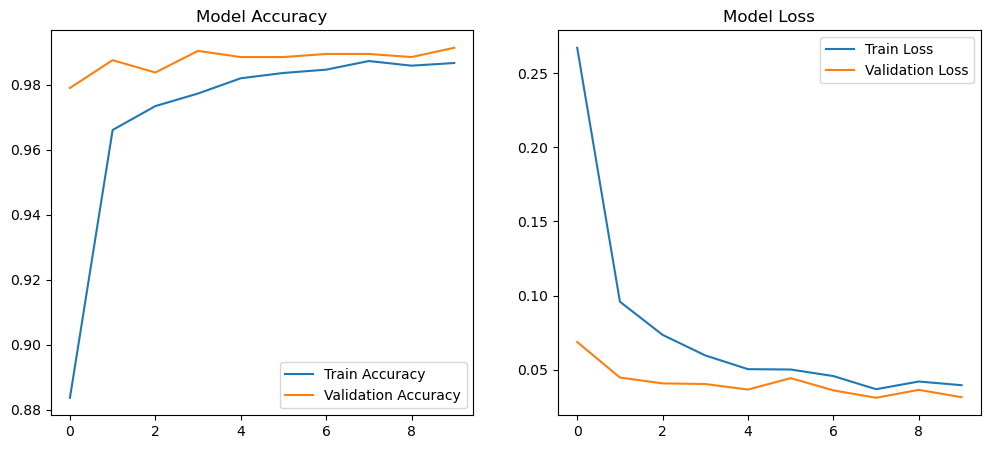

33/33 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9879 - loss: 0.0422
Test Accuracy: 98.86%
Test Loss: 0.0416
33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step


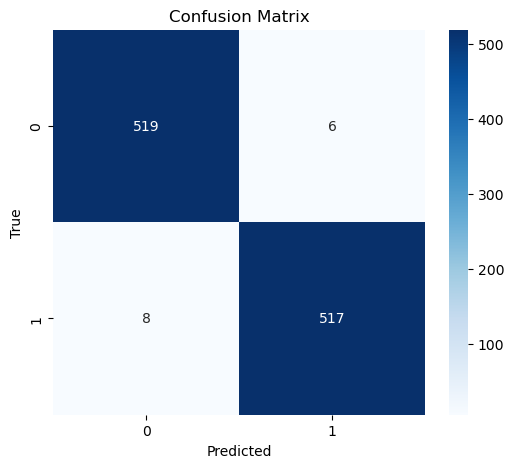


Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       525
          TB       0.99      0.98      0.99       525

    accuracy                           0.99      1050
   macro avg       0.99      0.99      0.99      1050
weighted avg       0.99      0.99      0.99      1050



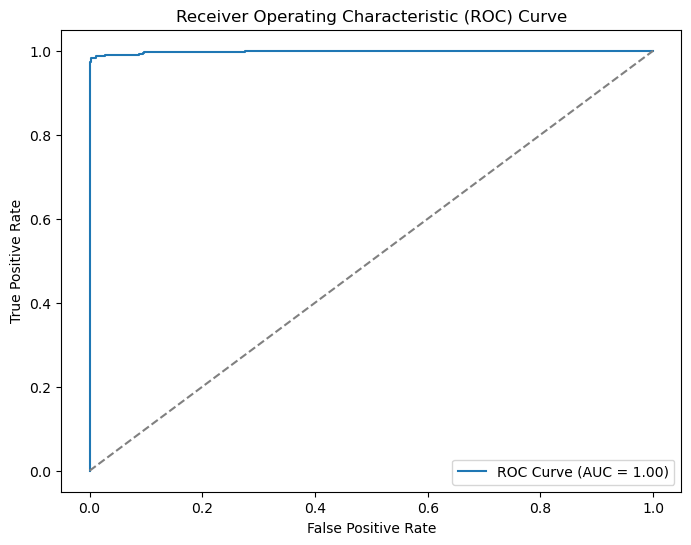

In [1]:
#10 Epochs  Mobilenet 

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Define dataset path
base_path = r'data/TB_Chest_Radiography_Database'

# Load and preprocess data
image_paths = []
labels = []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# Create DataFrame
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# Split dataset
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# Data Augmentation
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

######## Load MobileNetV2 (Pretrained)########
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model

# Build the Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

######### Evaluate on Test Set########
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Confusion Matrix & Classification Report######
y_true = test_df['label'].values  
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [2]:
model.save('mobilenet_tb_model.h5')


In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the uploaded model
model = load_model('mobilenet_tb_model.h5')

# Print model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,045,443 (11.62 MB)

 Trainable params: 787,457 (3.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [7]:
for layer in model.get_layer("mobilenetv2_1.00_224").layers:
    print(layer.name)


input_layer
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_ex